In [2]:
from analysis import *
from ellipsoid_fit import *


In [3]:
sphere_raw = process_file_to_raw_data("magnetometer_readings_16.txt")
sphere_raw = np.array([i for i in sphere_raw if np.linalg.norm(i) < 300])


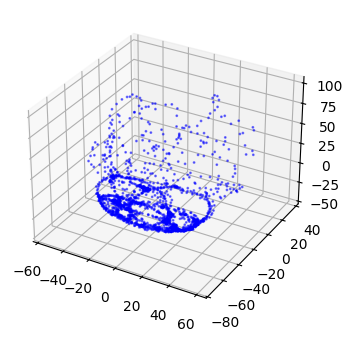

In [4]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')

# Original 3D data
ax.scatter(*sphere_raw.T, c='blue', marker='o', s=1, alpha=0.5)
plt.show()

In [5]:
points = np.concatenate((sphere_raw, ), axis=0)


In [6]:
# Fit the ellipsoid
center, R, radii = fit_ellipsoid_standard(points, linsolve=np.linalg.solve)
params = solution_to_params(center, R, radii)
print(R)
print(center)
print(radii)


[[ 0.60269274  0.78796204 -0.12600511]
 [ 0.79682194 -0.60275233  0.04200494]
 [ 0.04285158  0.12571971  0.9911399 ]]
[  4.86838557 -17.53454066  26.24906611]
[48.96104131 52.73976623 69.76183018]


In [7]:
center, R, radii = fit_ellipsoid_l2(points, params)
print(R)
print(center)
print(radii)

10 10 10
[[ 0.869896   -0.4914832   0.04153573]
 [ 0.49001663  0.85154527 -0.18642522]
 [ 0.05625531  0.18252375  0.98159076]]
[  6.06170798 -14.91233469  28.72095125]
[54.48860476 52.08671338 72.10644438]


In [8]:
center, R, radii = fit_ellipsoid_l1(points, params)
center, radii

(array([  7.31460684, -14.31328638,  24.90060692]),
 array([56.34395818, 54.35207056, 68.59616623]))

In [9]:
# Affine transformation from ellipsoid to unit sphere, keeping the orientation of the axes
def transform(data, center, evecs, radii):  
    # Translate to center
    data = data - center

    # Rotate to align with coordinate axes
    data = np.dot(data, evecs.T)

    # Scale to unit sphere
    for i in range(3):
        data[:, i] /= radii[i]
        
    # Rotate to align with original axes
    data = np.dot(data, evecs)

    return data

In [10]:
sphere_transformed = transform(sphere_raw, center, R, radii)

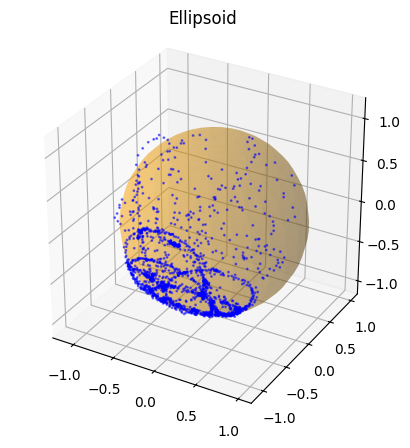

In [11]:
fig = plt.figure(figsize=(5, 5))

# Original data
ax1 = fig.add_subplot(111, projection='3d')
ax1.scatter(*sphere_transformed.T, c='blue', marker='o', s=1, alpha=0.5, label='Sphere Raw')
plot_ellipsoid(ax1)
set_axes_equal(ax1)
plt.show()

## Plot Transformed Ellipsoid

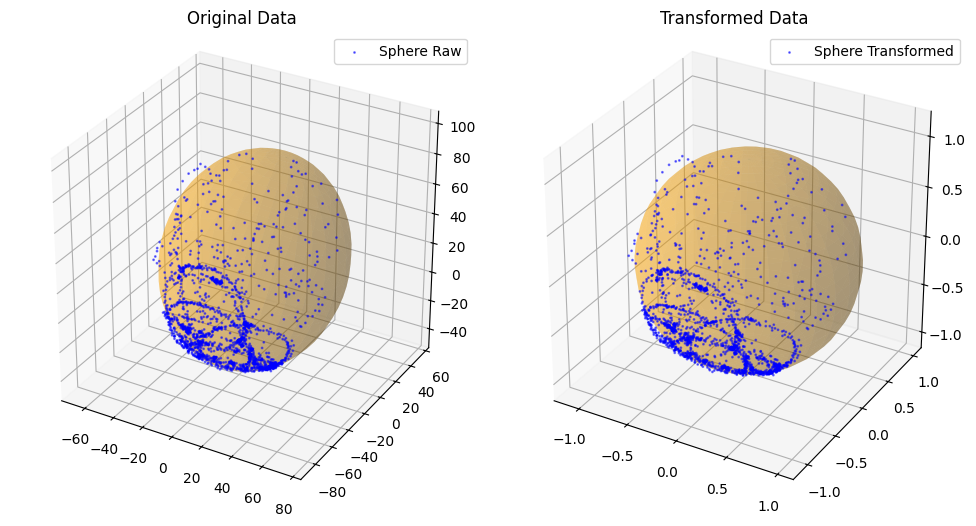

In [12]:
fig = plt.figure(figsize=(10, 5))

# Original data
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(*sphere_raw.T, c='blue', marker='o', s=1, alpha=0.5, label='Sphere Raw')
# ax1.scatter(*circle_raw.T, c='red', marker='o', s=1, alpha=0.5, label='Circle Raw')
plot_ellipsoid(ax1, center=center, R=R.T, radii=radii)
ax1.set_title("Original Data")
ax1.legend()
set_axes_equal(ax1)

# Transformed data
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(*sphere_transformed.T, c='blue', marker='o', s=1, alpha=0.5, label='Sphere Transformed')
# ax2.scatter(*circle_transformed.T, c='red', marker='o', s=1, alpha=0.5, label='Circle Transformed')
plot_ellipsoid(ax2)
ax2.set_title("Transformed Data")
ax2.legend()
set_axes_equal(ax2)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np

def construct_affine_matrix_with_two_rotations(center, evecs, radii):
    """
    Construct a 4x4 affine transformation matrix corresponding to the transform function
    with two rotations, scaling, and translation.
    
    Parameters:
        center (numpy.ndarray): 1x3 array representing the center of the ellipsoid.
        evecs (numpy.ndarray): 3x3 matrix of eigenvectors (axes of the ellipsoid).
        radii (numpy.ndarray): 1x3 array of ellipsoid radii.
    
    Returns:
        numpy.ndarray: 4x4 affine transformation matrix.
    """
    # Create a 4x4 identity matrix
    affine_matrix = np.eye(4)

    # Scaling matrix (3x3)
    scaling_matrix = np.diag(1 / radii)

    # First rotation: evecs.T (align ellipsoid axes with coordinate axes)
    first_rotation = evecs.T

    # Second rotation: evecs (rotate back to original orientation)
    second_rotation = evecs

    # Combine scaling and first rotation
    rotation_scaling_matrix = np.dot(scaling_matrix, first_rotation)

    # Combine with second rotation
    full_linear_transform = np.dot(second_rotation, rotation_scaling_matrix)

    # Insert the 3x3 linear transformation into the affine matrix
    affine_matrix[:3, :3] = full_linear_transform

    # Translation (negative center)
    affine_matrix[:3, 3] = -np.dot(full_linear_transform, center)

    return affine_matrix


In [16]:
A = construct_affine_matrix_with_two_rotations(center, R.T, radii)
print(A)
print("")
print_affine_matrix_formatted(A)


[[ 1.76225462e-02 -5.90947014e-05 -6.32561224e-04 -1.13996678e-01]
 [-5.90947014e-05  1.82600520e-02 -6.86524566e-04  2.78888487e-01]
 [-6.32561224e-04 -6.86524566e-04  1.48421710e-02 -3.74778551e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

// Affine transformation matrix (4x4)
const float AFFINE_TRANSFORMATION[4][4] = {
    {0.017623f, -0.000059f, -0.000633f, -0.113997f},
    {-0.000059f, 0.018260f, -0.000687f, 0.278888f},
    {-0.000633f, -0.000687f, 0.014842f, -0.374779f},
    {0.000000f, 0.000000f, 0.000000f, 1.000000f},
};


## Magnetic direction

In [15]:
# x,y,z = N, E, U
v = np.array([20903.9, -4062.0, 45840.8])
v /= np.linalg.norm(v)
print(v.tolist())

[0.4135656507192516, -0.08036317018458757, 0.9069207316094637]
